# Benchmark GARCH


In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')
df["date"] = pd.to_datetime(df["date"])
df.head()
df.info()
len(df)
df.isna().sum()
df = df.dropna()

# start from 2017-07-13
df = df[df["date"] >= "2017-07-13"]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3518 entries, 0 to 3517
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3518 non-null   datetime64[ns]
 1   log_return                                  3518 non-null   float64       
 2   realized_variance                           3518 non-null   float64       
 3   realized_volatility                         3518 non-null   float64       
 4   gtrend_pct_change                           3518 non-null   float64       
 5   blockchain_diff_log_n_transactions          3518 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64       
 9   log_volu

In [3]:
n = len(df)

train_size = int(n * 0.60)
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

train_df = df.iloc[train_start_idx:train_end_idx].copy()
eval_df  = df.iloc[eval_start_idx:eval_end_idx].copy() 
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set: {len(train_df)} rows")
print(f"Eval set:  {len(eval_df)} rows")
print(f"Test set:  {len(test_df)} rows")

Train set: 1875 rows
Eval set:  781 rows
Test set:  469 rows


In [4]:
def fit_garch_benchmark(returns, p=1, q=1, mean="constant", vol="GARCH", dist="t"):
    returns = pd.Series(returns).dropna().astype(float)

    if len(returns) < 200:
        return None

    try:
        am = arch_model(
            returns * 100.0,   
            mean=mean,
            vol=vol,
            p=p,
            q=q,
            dist=dist
        )
        res = am.fit(disp="off")
        return res
    except Exception:
        return None


def one_step_variance_forecast(fitted_model):
    if fitted_model is None:
        return np.nan

    try:
        fcast = fitted_model.forecast(horizon=1, reindex=False)
        var_100 = fcast.variance.values[-1, 0]
        return var_100 / (100.0 ** 2)   # scale back
    except Exception:
        return np.nan


def rolling_garch_benchmark_eval(
    df_full,
    start_idx,
    end_idx,
    return_col="log_return",
    realized_var_col="realized_variance",
    date_col="date",
    rolling_window=365,
    p=1,
    q=1,
    mean="constant",
    vol="GARCH",
    dist="t",
    min_obs=200
):
    results = []

    for t in range(start_idx - 1, end_idx - 1):
        train_start = max(0, t - rolling_window + 1)
        train_end = t + 1   

        train_slice = df_full.iloc[train_start:train_end].copy()
        train_returns = train_slice[return_col].dropna()

        next_row = df_full.iloc[t + 1]

        if len(train_returns) < min_obs:
            results.append({
                date_col: next_row[date_col],
                "actual_var": next_row[realized_var_col],
                "var_garch_bench": np.nan
            })
            continue

        fitted = fit_garch_benchmark(
            train_returns,
            p=p,
            q=q,
            mean=mean,
            vol=vol,
            dist=dist
        )

        var_forecast = one_step_variance_forecast(fitted)

        results.append({
            date_col: next_row[date_col],
            "actual_var": next_row[realized_var_col],
            "var_garch_bench": var_forecast
        })

    return pd.DataFrame(results)

In [5]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    if mask.sum() == 0:
        return np.nan

    yt = y_true[mask]
    yp = y_pred[mask]

    return np.mean(np.log(yp + eps) + yt / (yp + eps))


In [6]:
from arch import arch_model
from itertools import product

In [7]:
garch_grid = {
    "p": [1, 2, 3],
    "q": [1, 2,3]
}


garch_param_grid = []
for p, q, in product(
    garch_grid["p"],
    garch_grid["q"]
):
    garch_param_grid.append({
        "p": p,
        "q": q
    })

garch_results = []

for i, params in enumerate(garch_param_grid, 1):
    p = params["p"]
    q = params["q"]

    print(f"\n[{i}/{len(garch_param_grid)}] Testing GARCH: {params}")

    try: 
        res = rolling_garch_benchmark_eval(
            df_full=df,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            return_col="log_return",
            realized_var_col="realized_variance",
            date_col="date",
            rolling_window=365,
            p=p,
            q=q,
            mean="constant",
            vol="GARCH",
            dist="t",
            min_obs=200
        )

        eval_rmse = rmse(res["actual_var"], res["var_garch_bench"])
        eval_qlike = qlike(res["actual_var"], res["var_garch_bench"])

        valid_mask = (
            np.isfinite(res["actual_var"]) &
            np.isfinite(res["var_garch_bench"])
        )

        n_total = len(res)
        n_valid = valid_mask.sum()

        print(f"Eval RMSE : {eval_rmse:.6f}")
        print(f"Eval QLIKE: {eval_qlike:.6f}")
        print(f"Total rows    : {n_total}")
        print(f"Valid eval obs: {n_valid}")

        garch_results.append({
            "p": p,
            "q": q,
            "eval_rmse": eval_rmse,
            "eval_qlike": eval_qlike,
            "n_total": n_total,
            "n_valid": n_valid,
            "results_df": res
        })

    except Exception as e:
        print(f"Failed for p={p}, q={q}: {e}")
        



[1/9] Testing GARCH: {'p': 1, 'q': 1}
Eval RMSE : 0.001689
Eval QLIKE: -6.248726
Total rows    : 781
Valid eval obs: 781

[2/9] Testing GARCH: {'p': 1, 'q': 2}
Eval RMSE : 0.001676
Eval QLIKE: -6.266108
Total rows    : 781
Valid eval obs: 781

[3/9] Testing GARCH: {'p': 1, 'q': 3}
Eval RMSE : 0.001177
Eval QLIKE: -6.334450
Total rows    : 781
Valid eval obs: 781

[4/9] Testing GARCH: {'p': 2, 'q': 1}
Eval RMSE : 0.001713
Eval QLIKE: -6.241141
Total rows    : 781
Valid eval obs: 781

[5/9] Testing GARCH: {'p': 2, 'q': 2}
Eval RMSE : 0.001650
Eval QLIKE: -6.270950
Total rows    : 781
Valid eval obs: 781

[6/9] Testing GARCH: {'p': 2, 'q': 3}
Eval RMSE : 0.001154
Eval QLIKE: -6.340700
Total rows    : 781
Valid eval obs: 781

[7/9] Testing GARCH: {'p': 3, 'q': 1}
Eval RMSE : 0.001698
Eval QLIKE: -6.251192
Total rows    : 781
Valid eval obs: 781

[8/9] Testing GARCH: {'p': 3, 'q': 2}
Eval RMSE : 0.001673
Eval QLIKE: -6.265913
Total rows    : 781
Valid eval obs: 781

[9/9] Testing GARCH: {'

In [9]:
garch_results_df = pd.DataFrame(garch_results).sort_values("eval_qlike")
print(garch_results_df.head())

   p  q  eval_rmse  eval_qlike  n_total  n_valid  \
5  2  3   0.001154   -6.340700      781      781   
2  1  3   0.001177   -6.334450      781      781   
8  3  3   0.001194   -6.332327      781      781   
4  2  2   0.001650   -6.270950      781      781   
1  1  2   0.001676   -6.266108      781      781   

                                          results_df  
5            date  actual_var  var_garch_bench
0 ...  
2            date  actual_var  var_garch_bench
0 ...  
8            date  actual_var  var_garch_bench
0 ...  
4            date  actual_var  var_garch_bench
0 ...  
1            date  actual_var  var_garch_bench
0 ...  


In [11]:
best_garch_params = garch_results_df.iloc[0].to_dict()

best_p = int(best_garch_params["p"])
best_q = int(best_garch_params["q"])

best_p, best_q


(2, 3)

#### out of sample test

In [12]:
test_garch = rolling_garch_benchmark_eval(
    df_full=df,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    return_col="log_return",
    realized_var_col="realized_variance",
    date_col="date",
    rolling_window=365,
    p=best_p,
    q=best_q,
    mean="constant",
    vol="GARCH",
    dist="t",
    min_obs=200
)

test_rmse = rmse(test_garch["actual_var"], test_garch["var_garch_bench"])
test_qlike = qlike(test_garch["actual_var"], test_garch["var_garch_bench"])

print("Final Test RMSE :", test_rmse)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_garch["var_garch_bench"].notna().sum())

Final Test RMSE : 0.0006515314758017452
Final Test QLIKE: -6.544082532959463
Number of test forecasts: 469


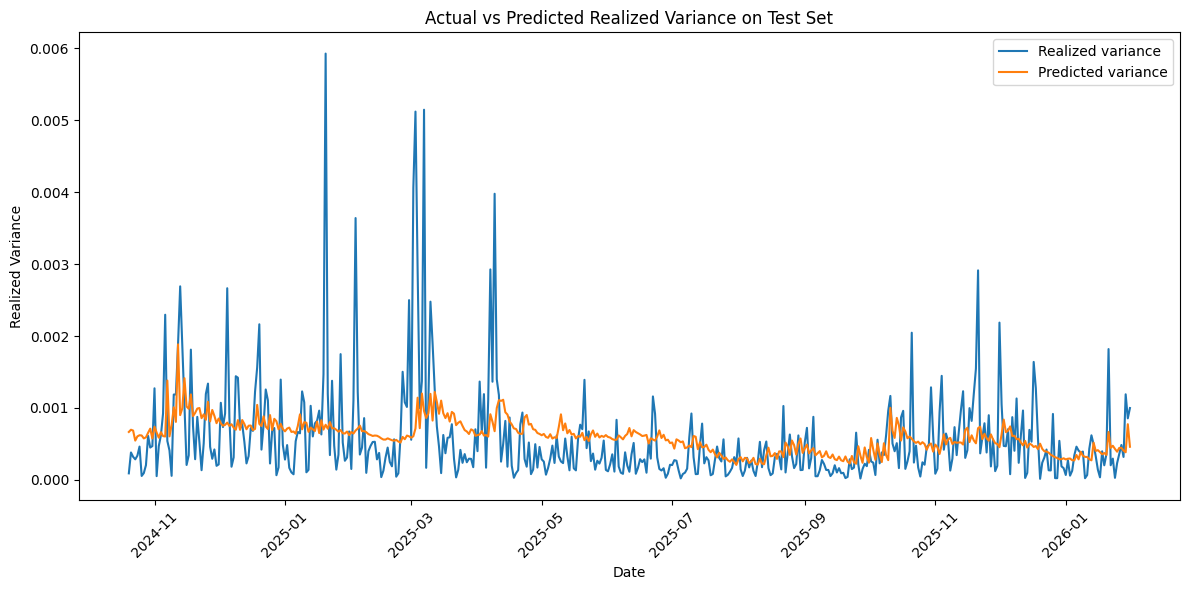

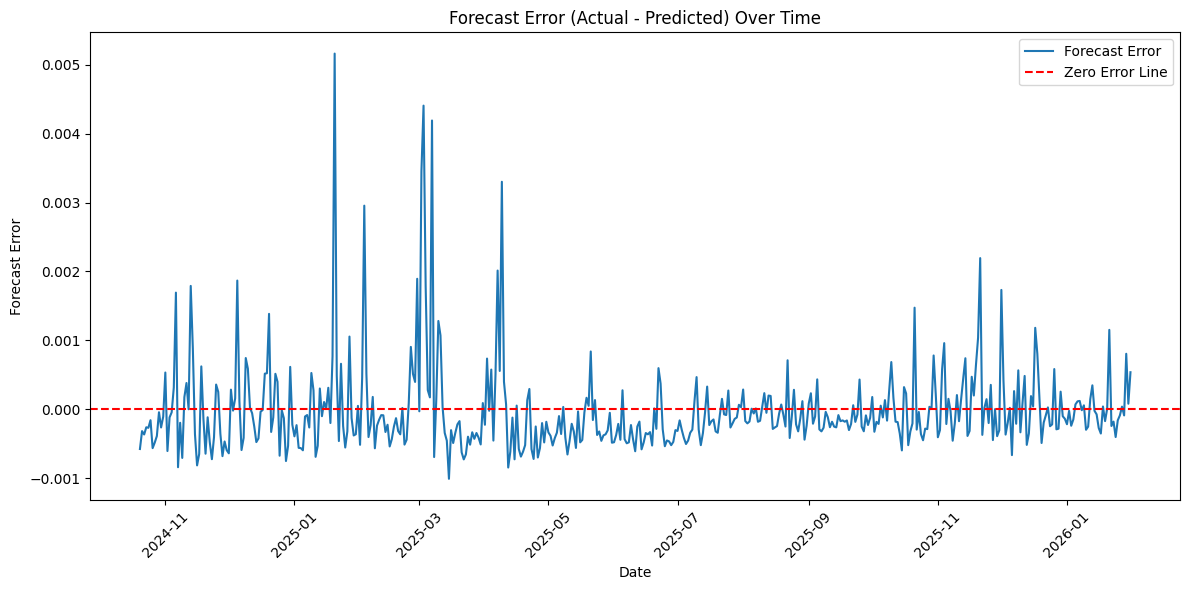

In [17]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_garch['date'] = pd.to_datetime(test_garch['date'])
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], test_garch["actual_var"], label="Realized variance")
plt.plot(test_garch["date"], test_garch["var_garch_bench"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_garch['date'] = pd.to_datetime(test_garch['date'])
test_garch['error'] = test_garch["actual_var"] - test_garch["var_garch_bench"]
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], test_garch["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# save final results and export test predictions
test_garch.to_csv("garch.csv", index=False)

In [17]:
test_rmse*1000

0.6443637943008511